# Hidden Markov Model Foundations

| Tutorial status | Details |
|---|---|
| **Course role** | Core temporal latent-variable model between mixtures and AR-HMMs |
| **Expected runtime** | Under 2 minutes |
| **Hardware** | CPU |
| **External data** | None |
| **Validation** | Self-contained Gaussian HMM simulation, inference, decoding, and EM |

A hidden Markov model (HMM) adds temporal dependence to the discrete
assignments of a mixture model. Dynamic programming then replaces an
exponential sum over $K^T$ state sequences with $O(TK^2)$ inference.

This compact notebook is the core prerequisite for the extended
`03_hmm_lds.ipynb` AR-HMM and MoSeq workshop.

## 1. From mixtures to Markov states

For latent states $z_t\in\{1,\ldots,K\}$ and observations $\mathbf{x}_t$,

$$
p(z_{1:T},\mathbf{x}_{1:T})
=p(z_1)\prod_{t=2}^T p(z_t\mid z_{t-1})
\prod_{t=1}^T p(\mathbf{x}_t\mid z_t).
$$

The model has three components:

| Component | Parameter | Interpretation |
|---|---|---|
| Initial distribution | $\boldsymbol{\pi}_0$ | state probability before the sequence begins |
| Transition matrix | $\mathbf{P}$ | $P_{ij}=p(z_{t+1}=j\mid z_t=i)$ |
| Emission model | $p(\mathbf{x}_t\mid z_t=k)$ | state-specific observation distribution |

Every row of $\mathbf{P}$ sums to one. Large diagonal entries encode persistent
states, a common feature of neural and behavioral sequences.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})
rng = np.random.default_rng(13)

## 2. Synthetic Gaussian HMM

We use one-dimensional Gaussian emissions so the latent sequence, noisy
observations, filtering probabilities, and smoothed probabilities can all be
compared directly.

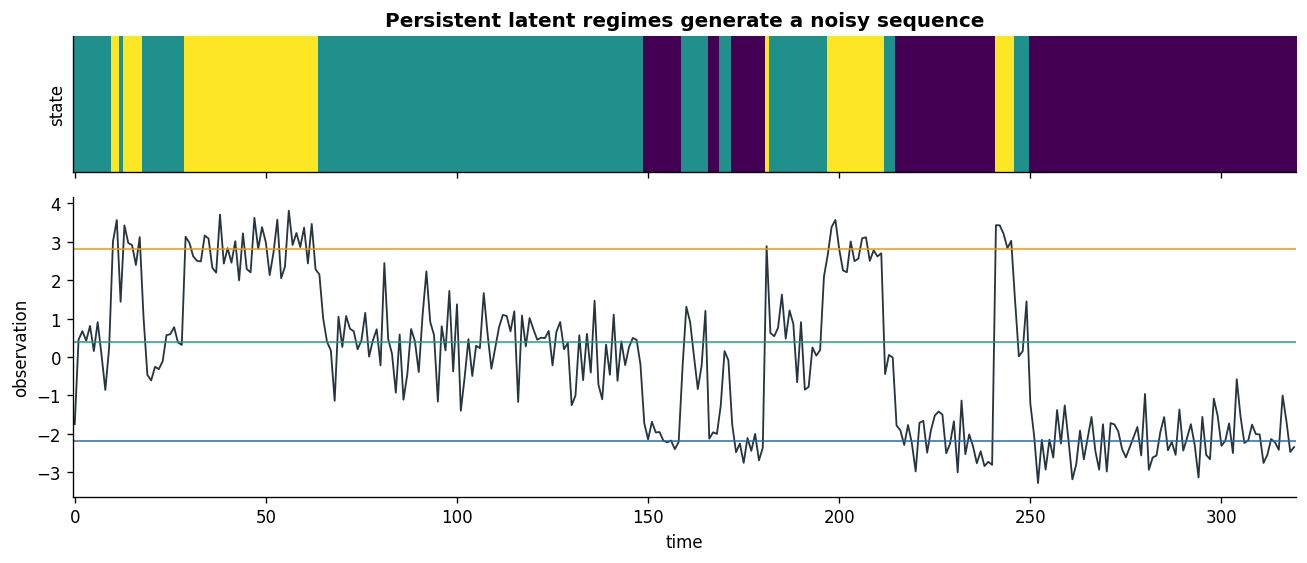

In [2]:
initial_true = np.array([0.65, 0.25, 0.10])
transition_true = np.array([
    [0.94, 0.05, 0.01],
    [0.04, 0.91, 0.05],
    [0.02, 0.07, 0.91],
])
means_true = np.array([-2.2, 0.4, 2.8])
scales_true = np.array([0.55, 0.70, 0.50])

num_steps = 320
states_true = np.empty(num_steps, dtype=int)
observations = np.empty(num_steps)
states_true[0] = rng.choice(3, p=initial_true)
observations[0] = rng.normal(means_true[states_true[0]], scales_true[states_true[0]])
for t in range(1, num_steps):
    states_true[t] = rng.choice(3, p=transition_true[states_true[t - 1]])
    observations[t] = rng.normal(means_true[states_true[t]], scales_true[states_true[t]])

state_colors = np.array([[0.16, 0.39, 0.65], [0.08, 0.62, 0.51], [0.93, 0.58, 0.05]])
fig, axes = plt.subplots(2, 1, figsize=(11, 4.8), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2.2]})
axes[0].imshow(states_true[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=2)
axes[0].set(ylabel="state", yticks=[], title="Persistent latent regimes generate a noisy sequence")
axes[1].plot(observations, color="#263640", linewidth=1.1)
for mean, color in zip(means_true, state_colors):
    axes[1].axhline(mean, color=color, linewidth=1.2, alpha=0.75)
axes[1].set(xlabel="time", ylabel="observation")
plt.tight_layout()

## 3. Scaled forward recursion

Let $\ell_{tk}=p(x_t\mid z_t=k)$. The filtering recursion is

$$
\widehat{\boldsymbol{\alpha}}_t
=\left(\boldsymbol{\alpha}_{t-1}^{\top}\mathbf{P}\right)
\odot\boldsymbol{\ell}_t,
\qquad
c_t=\sum_k\widehat{\alpha}_{tk},
\qquad
\boldsymbol{\alpha}_t=\frac{\widehat{\boldsymbol{\alpha}}_t}{c_t}.
$$

Here $\alpha_{tk}=p(z_t=k\mid x_{1:t})$ and
$c_t=p(x_t\mid x_{1:t-1})$. Therefore

$$
\log p(x_{1:T})=\sum_{t=1}^T\log c_t.
$$

Normalizing at every step prevents products of small probabilities from
underflowing.

In [3]:
def gaussian_emission_probabilities(data, means, scales):
    standardized = (data[:, None] - means[None, :]) / scales[None, :]
    probabilities = np.exp(-0.5 * standardized**2) / (np.sqrt(2 * np.pi) * scales[None, :])
    return np.maximum(probabilities, np.finfo(float).tiny)


def forward_filter(emissions, initial, transition):
    t_max, num_states = emissions.shape
    filtered = np.empty((t_max, num_states))
    scales = np.empty(t_max)
    predictive = initial.copy()
    for t in range(t_max):
        joint = predictive * emissions[t]
        scales[t] = joint.sum()
        filtered[t] = joint / scales[t]
        predictive = filtered[t] @ transition
    return filtered, scales, np.log(scales).sum()


emissions_true = gaussian_emission_probabilities(observations, means_true, scales_true)
filtered_true, scaling_constants, log_likelihood_true = forward_filter(
    emissions_true, initial_true, transition_true
)
print(f"Sequence log likelihood: {log_likelihood_true:.2f}")
print("Filtering rows sum to one:", np.allclose(filtered_true.sum(axis=1), 1.0))

Sequence log likelihood: -369.49
Filtering rows sum to one: True


## 4. Backward messages and smoothing

The scaled backward recursion is

$$
\boldsymbol{\beta}_t
=\frac{\mathbf{P}
(\boldsymbol{\ell}_{t+1}\odot\boldsymbol{\beta}_{t+1})}{c_{t+1}},
\qquad \boldsymbol{\beta}_T=\mathbf{1}.
$$

Combining past and future evidence gives the smoothed posterior

$$
\gamma_{tk}=p(z_t=k\mid x_{1:T})
\propto \alpha_{tk}\beta_{tk}.
$$

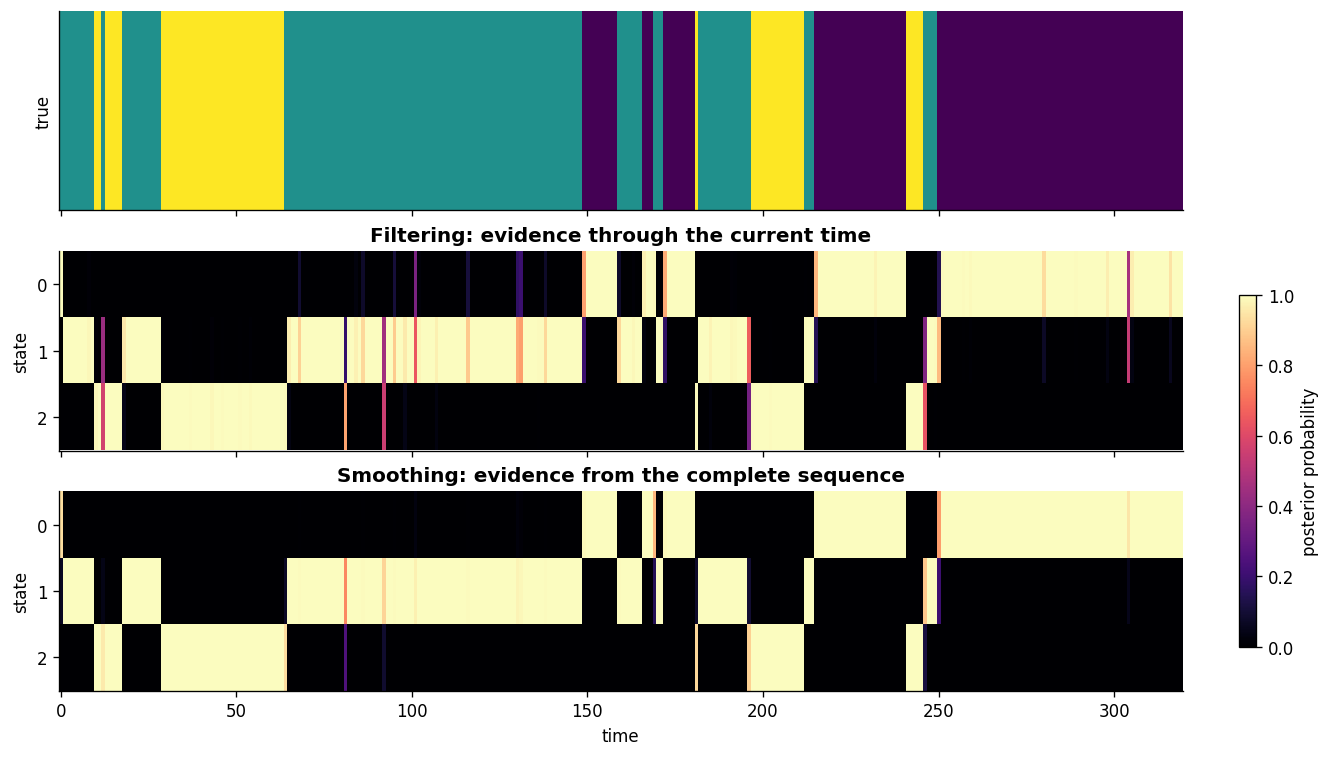

In [4]:
def forward_backward(emissions, initial, transition):
    filtered, scales, log_likelihood = forward_filter(emissions, initial, transition)
    backward = np.ones_like(filtered)
    for t in range(len(emissions) - 2, -1, -1):
        backward[t] = transition @ (emissions[t + 1] * backward[t + 1]) / scales[t + 1]

    smoothed = filtered * backward
    smoothed /= smoothed.sum(axis=1, keepdims=True)

    pairwise = np.empty((len(emissions) - 1, transition.shape[0], transition.shape[1]))
    for t in range(len(emissions) - 1):
        pairwise[t] = (
            filtered[t, :, None]
            * transition
            * (emissions[t + 1] * backward[t + 1])[None, :]
        )
        pairwise[t] /= pairwise[t].sum()
    return filtered, smoothed, pairwise, log_likelihood


filtered, smoothed, pairwise, _ = forward_backward(
    emissions_true, initial_true, transition_true
)
assert np.allclose(smoothed.sum(axis=1), 1.0)
assert np.allclose(pairwise.sum(axis=(1, 2)), 1.0)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.2), sharex=True, constrained_layout=True)
axes[0].imshow(states_true[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=2)
axes[0].set(ylabel="true", yticks=[])
axes[1].imshow(filtered.T, aspect="auto", cmap="magma", vmin=0, vmax=1)
axes[1].set(ylabel="state", title="Filtering: evidence through the current time")
image = axes[2].imshow(smoothed.T, aspect="auto", cmap="magma", vmin=0, vmax=1)
axes[2].set(xlabel="time", ylabel="state", title="Smoothing: evidence from the complete sequence")
fig.colorbar(image, ax=axes[1:], label="posterior probability", shrink=0.8)

## 5. Pairwise marginals

EM needs expected transition counts, not only state marginals:

$$
\xi_{tij}
=p(z_t=i,z_{t+1}=j\mid x_{1:T})
\propto
\alpha_{ti}P_{ij}\ell_{t+1,j}\beta_{t+1,j}.
$$

Summing $\xi_{tij}$ over time gives the expected number of transitions from
state $i$ to state $j$.

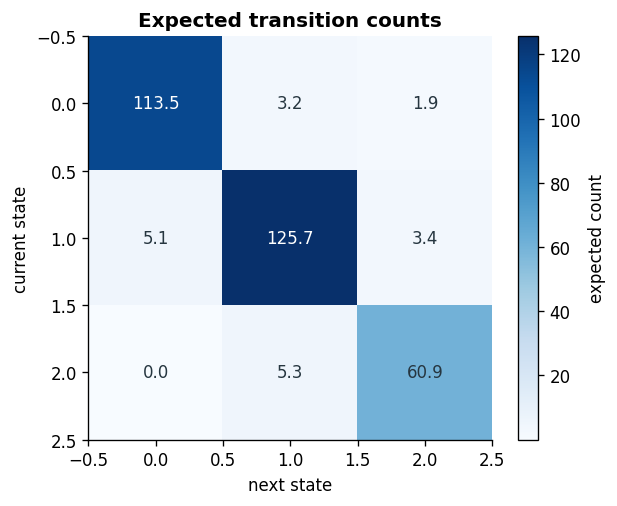

In [5]:
expected_transitions = pairwise.sum(axis=0)
fig, ax = plt.subplots(figsize=(5.3, 4.3))
image = ax.imshow(expected_transitions, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{expected_transitions[i, j]:.1f}", ha="center", va="center",
                color="white" if expected_transitions[i, j] > expected_transitions.max() / 2 else "#263640")
ax.set(xlabel="next state", ylabel="current state", title="Expected transition counts")
fig.colorbar(image, ax=ax, label="expected count")
plt.tight_layout()

## 6. Three different posterior questions

These operations are related but not interchangeable:

| Goal | Output | Algorithm |
|---|---|---|
| Marginal uncertainty | $p(z_t\mid x_{1:T})$ | forward-backward |
| Most likely joint path | $\arg\max_{z_{1:T}}p(z_{1:T}\mid x_{1:T})$ | Viterbi |
| Uncertainty over complete paths | $z_{1:T}\sim p(z_{1:T}\mid x_{1:T})$ | backward sampling |

Taking `argmax` of each marginal independently does not generally produce the
Viterbi path because it ignores transition compatibility.

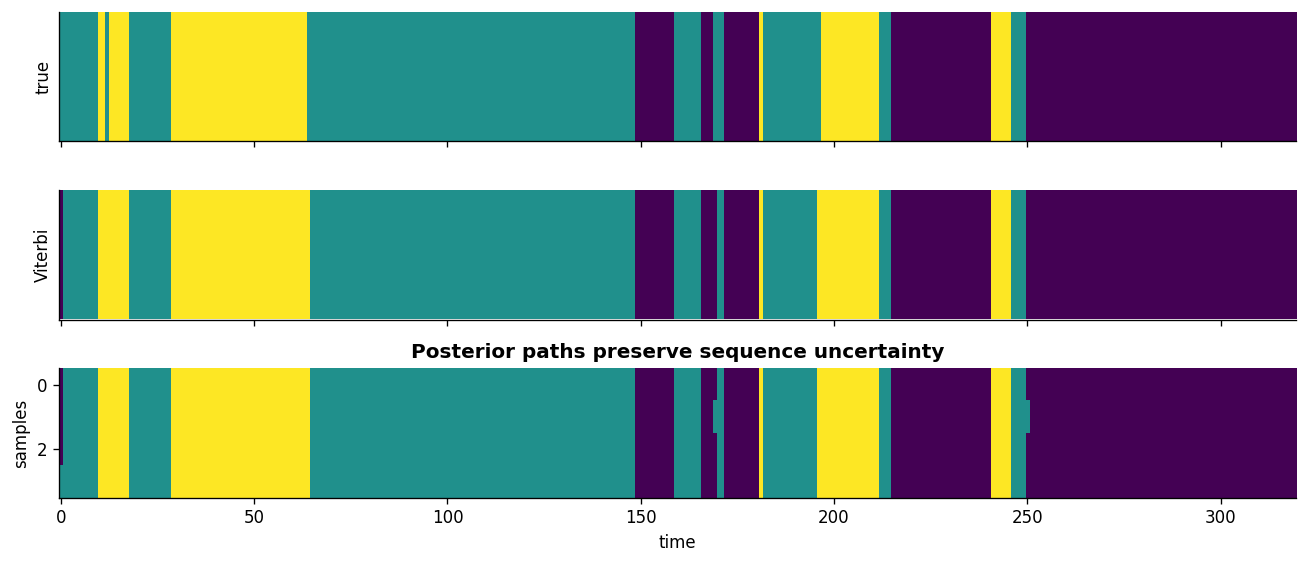

In [6]:
def viterbi(log_emissions, initial, transition):
    scores = np.empty_like(log_emissions)
    parents = np.empty_like(log_emissions, dtype=int)
    scores[0] = np.log(initial) + log_emissions[0]
    for t in range(1, len(log_emissions)):
        candidates = scores[t - 1, :, None] + np.log(transition)
        parents[t] = candidates.argmax(axis=0)
        scores[t] = candidates.max(axis=0) + log_emissions[t]
    path = np.empty(len(log_emissions), dtype=int)
    path[-1] = scores[-1].argmax()
    for t in range(len(path) - 2, -1, -1):
        path[t] = parents[t + 1, path[t + 1]]
    return path


def sample_posterior_path(filtered, transition, generator):
    path = np.empty(len(filtered), dtype=int)
    path[-1] = generator.choice(filtered.shape[1], p=filtered[-1])
    for t in range(len(path) - 2, -1, -1):
        probabilities = filtered[t] * transition[:, path[t + 1]]
        probabilities /= probabilities.sum()
        path[t] = generator.choice(filtered.shape[1], p=probabilities)
    return path


viterbi_path = viterbi(np.log(emissions_true), initial_true, transition_true)
posterior_paths = np.vstack([
    sample_posterior_path(filtered, transition_true, rng) for _ in range(4)
])

fig, axes = plt.subplots(3, 1, figsize=(11, 4.8), sharex=True)
axes[0].imshow(states_true[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=2)
axes[0].set(ylabel="true", yticks=[])
axes[1].imshow(viterbi_path[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=2)
axes[1].set(ylabel="Viterbi", yticks=[])
axes[2].imshow(posterior_paths, aspect="auto", cmap="viridis", vmin=0, vmax=2)
axes[2].set(xlabel="time", ylabel="samples", title="Posterior paths preserve sequence uncertainty")
plt.tight_layout()

## 7. Baum-Welch: EM for an HMM

The E-step runs forward-backward. The M-step normalizes expected sufficient
statistics:

$$
\pi_{0k}^{\mathrm{new}}=\gamma_{1k},
\qquad
P_{ij}^{\mathrm{new}}
=\frac{\sum_{t=1}^{T-1}\xi_{tij}}
{\sum_{t=1}^{T-1}\gamma_{ti}},
$$

$$
\mu_k^{\mathrm{new}}
=\frac{\sum_t\gamma_{tk}x_t}{\sum_t\gamma_{tk}},
\qquad
(\sigma_k^2)^{\mathrm{new}}
=\frac{\sum_t\gamma_{tk}(x_t-\mu_k^{\mathrm{new}})^2}
{\sum_t\gamma_{tk}}.
$$

Estimated transition matrix (ordered labels may differ):
[[0.965 0.018 0.017]
 [0.037 0.939 0.024]
 [0.    0.078 0.922]]


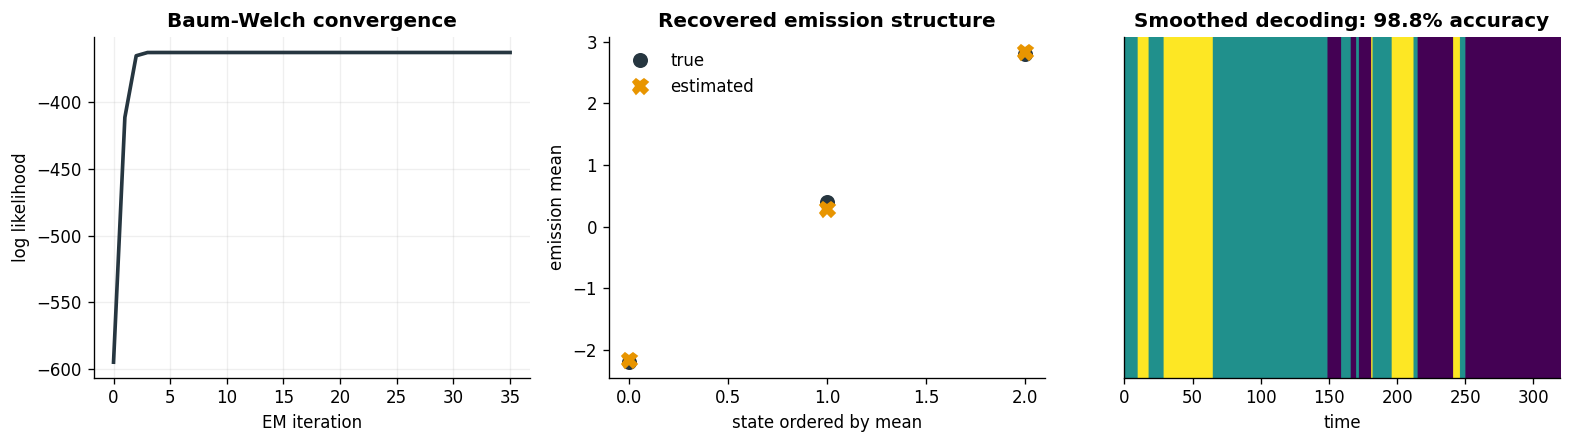

In [7]:
def fit_gaussian_hmm(data, num_states=3, num_iterations=35):
    initial = np.ones(num_states) / num_states
    transition = np.full((num_states, num_states), 0.15 / (num_states - 1))
    np.fill_diagonal(transition, 0.85)
    means = np.quantile(data, np.linspace(0.15, 0.85, num_states))
    scales = np.full(num_states, data.std())
    history = []

    for _ in range(num_iterations):
        emissions = gaussian_emission_probabilities(data, means, scales)
        _, gamma, xi, log_likelihood = forward_backward(emissions, initial, transition)
        history.append(log_likelihood)

        initial = gamma[0] + 1e-8
        initial /= initial.sum()
        transition = xi.sum(axis=0) + 1e-6
        transition /= transition.sum(axis=1, keepdims=True)
        counts = gamma.sum(axis=0) + 1e-8
        means = gamma.T @ data / counts
        variances = np.sum(gamma * (data[:, None] - means[None, :]) ** 2, axis=0) / counts
        scales = np.sqrt(np.maximum(variances, 1e-4))

    emissions = gaussian_emission_probabilities(data, means, scales)
    filtered, gamma, xi, final_log_likelihood = forward_backward(emissions, initial, transition)
    history.append(final_log_likelihood)
    assert np.all(np.diff(history) >= -1e-5)
    return (initial, transition, means, scales), filtered, gamma, np.asarray(history)


(initial_fit, transition_fit, means_fit, scales_fit), filtered_fit, smoothed_fit, em_history = fit_gaussian_hmm(observations)
order = np.argsort(means_fit)
rank = np.empty_like(order)
rank[order] = np.arange(len(order))
decoded_fit = rank[smoothed_fit.argmax(axis=1)]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
axes[0].plot(em_history, color="#263640", linewidth=2.2)
axes[0].set(xlabel="EM iteration", ylabel="log likelihood", title="Baum-Welch convergence")
axes[0].grid(alpha=0.2)

axes[1].plot(means_true, "o", label="true", color="#263640", markersize=8)
axes[1].plot(np.sort(means_fit), "X", label="estimated", color="#e89500", markersize=9)
axes[1].set(xlabel="state ordered by mean", ylabel="emission mean", title="Recovered emission structure")
axes[1].legend(frameon=False)

axes[2].imshow(decoded_fit[None, :], aspect="auto", cmap="viridis", vmin=0, vmax=2)
axes[2].set(xlabel="time", yticks=[], title=f"Smoothed decoding: {(decoded_fit == states_true).mean():.1%} accuracy")
plt.tight_layout()

print("Estimated transition matrix (ordered labels may differ):")
print(np.round(transition_fit, 3))

## 8. What this prepares you for

The same message-passing pattern appears throughout latent dynamical modeling:

- Gaussian HMMs replace independent mixture assignments with persistent states.
- AR-HMMs let each state define its own autoregressive dynamics.
- SLDS models combine discrete regimes with continuous latent trajectories.
- Variational methods replace exact messages when conjugacy or tractability is lost.

### Takeaways

- Scaling constants provide both numerical stability and the marginal likelihood.
- Filtering uses past evidence; smoothing also uses future evidence.
- Pairwise marginals are required to learn transitions.
- Viterbi decoding and posterior sampling answer different questions.
- Baum-Welch is EM with forward-backward as its E-step.

Continue to `03_hmm_lds.ipynb` for the extended Gaussian/AR-HMM workshop and
the optional MoSeq/NWB application.